# Deep Agent

- Build agents that can plan, use subagents, and leverage file system for complex tasks
    - deepagents is a standalone library for building agents that can tackle complex, multi-step tasks. built on langgraph and insipired by applications like claude code, Deep Research, and manus, deep agents come with planning capabilities, file sysetms for context managment, and the ability to span subagents.

### when to use deep agents.
- Handle complex multi step tasks that require planning and decomposition.
- Manage large amounts of context through file system tools
- Delegate work to specialiized subagents for context isolation
- Persist memory across conversations and threads



In [2]:
# Basic Deep Agents

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [3]:
### Tools - Internet search
from tavily import TavilyClient
from typing import Literal

tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def web_search(query: str, max_results:int=5,
topic: Literal["sports","news","finance"]="general",
include_raw_content:bool=False):
    """Run a web search"""
    return tavily_client.search(query, max_results= max_results,include_raw_content= include_raw_content,topic = topic)
  


In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.chat_models import init_chat_model

llm = ChatGoogleGenerativeAI(model="gemini-3.8-flash")
llm

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.2', 'langchain-google-genai': '4.4.0'}}, profile={}, google_api_key=SecretStr('**********'), model='gemini-3.8-flash', temperature=None, client=<google.genai.client.Client object at 0x79b23fd54aa0>, default_metadata=(), model_kwargs={})

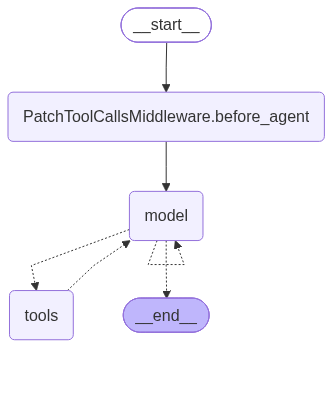

In [5]:
## create a deep agent
from deepagents import create_deep_agent

# prompt
deep_agent = create_deep_agent(
    model=llm,
    tools=[web_search],
    system_prompt="Act as a researcher"
)

# agent
deep_agent


In [7]:
result = deep_agent.invoke({"messages":{"role":"user","content":"what is langGraph"}})
result["messages"][-1].content

[{'type': 'text',
  'text': '# What is LangGraph? An Architectural and Research Overview\n\n**LangGraph** is an open-source framework developed by LangChain Inc. designed for orchestrating **stateful, multi-actor, and cyclical** LLM (Large Language Model) applications. \n\nWhile traditional LLM pipelines (such as standard LangChain Expression Language or basic RAG pipelines) model operations as Directed Acyclic Graphs (DAGs) or linear chains, LangGraph models agentic workflows as **cyclic graphs**. This architecture provides native support for iterative reasoning loops, branching, memory persistence, and multi-agent coordination.\n\n---\n\n## 1. Motivation: Why LangGraph?\n\nEarly LLM orchestration frameworks primarily relied on linear or DAG execution models:\n\n$$\\text{Input} \\longrightarrow \\text{Prompt} \\longrightarrow \\text{LLM} \\longrightarrow \\text{Tool Output} \\longrightarrow \\text{Final Response}$$\n\nWhile sufficient for single-turn Q&A and basic Retrieval-Augmented 

In [ ]:
#  What is LangGraph? An Architectural and Research Overview\n\n**LangGraph**
# is an open-source framework developed by LangChain Inc.
# designed for orchestrating **stateful, multi-actor,
# and cyclical** LLM (Large Language Model) applications. 
# \n\nWhile traditional LLM pipelines (such as standard LangChain Expression Language or basic RAG pipelines) 

# model operations as Directed Acyclic Graphs (DAGs) or linear chains,
# LangGraph models agentic workflows as **cyclic graphs**. 
# This architecture provides native support for iterative reasoning loops,
#  branching, memory persistence, and multi-agent coordination.\n\n---\n\n##
# 1. Motivation: Why LangGraph?\n\nEarly LLM orchestration frameworks primarily relied on linear or DAG execution models:\n\n$$\\text{Input} \\
# longrightarrow \\text{Prompt} \\longrightarrow \\text{LLM} \\longrightarrow \\text{Tool Output} 
# \\longrightarrow \\text{Final Response}$$\n\nWhile sufficient for single-turn Q&A and basic Retrieval-Augmented Generation (RAG), 
# real-world autonomous agents require:\n* **Cyclical decision loops:** 
# Allowing an agent to evaluate tool outputs, inspect errors, reflect, 
# and re-attempt steps until a stopping condition is met.\n*
# **Complex branching:** Routing execution paths dynamically based on runtime outputs.\n* 
# **State synchronization:** Managing shared, mutable, or accumulating state across multiple steps or collaborating sub-agents.\n
# **Human-in-the-loop (HITL):** Pausing execution to seek human confirmation or edits, then resuming from that exact state.
# \n\nLangGraph was developed specifically to formalize these agentic patterns into a robust, 
# observable graph-based execution runtime.\n\n---\n\n## 2. Core Architectural Concepts\n\nLangGraph 
# structures computation around three fundamental primitives: **State**, **Nodes**, and **Edges**, supplemented by a **Checkpointer**.\n\n```\n             ┌────────────────┐\n             │     State      │  (Shared schema across steps)\n             └───────┬────────┘\n                     │\n         ┌───────────▼───────────┐\n         │         Node          │ (Function: State -> Partial State)\n         └───────────┬───────────┘\n                     │\n             ┌───────▼────────┐\n             │Condition / Edge│  (Determines next node)\n             └───┬─────────┬──┘\n                 │         │\n        [Loop / Retry]   [Next Step / END]\n```\n\n### 1. State (`Schema`)\nThe graph is parameterized by a centralized state schema (commonly defined via Pydantic or Python `TypedDict`). \n* Every node reads from and returns updates to this state.\n* **Reducers:** When nodes emit updates, reducer functions (e.g., `operator.add` to append messages to a list, or replace-in-place for specific attributes) dictate how updates are merged into the global state.\n\n### 2. Nodes (`Nodes`)\nNodes represent discrete units of work. A node is typically a Python function or runnable that:\n1. Receives the current `State` as input.\n2. Performs computation (e.g., calling an LLM, querying a vector store, invoking external APIs, running code).\n3. Returns a dictionary of updates to be merged into the `State`.\n\n### 3. Edges (`Edges`)\nEdges govern the control flow between nodes:\n* **Standard (Normal) Edges:** Direct, deterministic transitions (e.g., `Node A -> Node B`).\n* **Conditional Edges:** Dynamic routing functions that inspect the state and determine the next destination node (e.g., if the LLM generated a tool call, route to `tools`; if it answered, route to `END`).\n* **Entry and Exit Points:** Special edges marking `START` and `END`.\n\n### 4. Checkpointing & Persistence\nLangGraph features a built-in checkpointing layer (using in-memory, SQLite, PostgreSQL, Redis, etc.) that snapshots the entire state graph at each super-step. This unlocks:\n* **Fault Tolerance & Resumability:** Failures can be recovered without restarting the workflow from scratch.\n* **Time-Travel Debugging:** Developers can rewind state, modify variables or prompts, and re-run execution branches from an arbitrary checkpoint.\n* **Human-in-the-loop (HITL):** Graphs can be interrupted before or after node execution, allowing humans to inspect, approve, or alter proposed agent actions before state mutations persist.\n\n---\n\n## 3. Multi-Agent Architectures Supported\n\nLangGraph is widely adopted for orchestrating multi-agent systems. It naturally supports several common multi-agent topologies:\n\n| Pattern | Description | Typical Use Case |\n| :--- | :--- | :--- |\n| **Supervisor / Router** | A central coordinator agent determines which specialized sub-agent (e.g., coder, researcher, reviewer) should act next. | Complex domain-specific problem solving with clear role divisions. |\n| **Hierarchical Teams** | Top-level supervisors delegate to sub-graphs (sub-teams) that handle sub-tasks independently before aggregating findings. | Enterprise workflows, multi-step research reports. |\n| **Network / Peer-to-Peer** | Autonomous agents communicate through shared state or explicit messaging edges without a centralized controller. | Collaborative debate, consensus-building algorithms. |\n\n---\n\n## 4. LangGraph vs. Alternatives\n\n| Feature / Dimension | LangChain (LCEL) | LangGraph | AutoGen | CrewAI |\n| :--- | :--- | :--- | :--- | :--- |\n| **Execution Topology** | Linear / DAG | Cyclical Graphs | Conversational Event-Loop | Sequential / Hierarchical Task Chains |\n| **Control Granularity** | High (chains) | Fine-grained (explicit state & transitions) | High-level (conversational agents) | High-level (role/task-based abstraction) |\n| **State Management** | Ephemeral / Basic memory | First-class, versioned, snapshot-capable | Message history | Task context & memory |\n| **Human-in-the-Loop** | Manual handling | First-class (interrupts & checkpoints) | Console / conversational input | Built-in human approval prompts |\n| **Best Suited For** | Deterministic RAG, data pipelines | Production-grade agents, complex stateful loops | Conversational simulation, research prototypes | Rapid prototyping of role-playing teams |\n\n---\n\n## 5. Strengths and Limitations\n\n### Strengths\n1. **Deterministic Control over Non-deterministic Models:** Unlike purely black-box agent runtimes, LangGraph forces explicit definition of transitions and state boundaries, significantly reducing erratic agent drift.\n2. **First-Class Time Travel and Durability:** Built-in persistence makes it suitable for long-running workflows that span minutes, hours, or asynchronous human interactions.\n3. **Multi-language Support:** Available in both Python (`langgraph`) and TypeScript/JavaScript (`@langchain/langgraph`).\n\n### Limitations & Trade-offs\n1. **Steeper Learning Curve:** Requires understanding state reducers, edge semantics, and graph topologies compared to plug-and-play role frameworks like CrewAI.\n2. **Boilerplate:** Designing custom state schemas, reducer operations, and conditional edges introduces more upfront code than purely conversational abstractions.\n\n---\n\n## Summary\n\nIn modern AI systems engineering, **LangGraph serves as the runtime and state machine for agentic workflows**. It bridges the gap between simple chained LLM calls and complex, self-correcting autonomous multi-agent systems,
# prioritizing control, state auditability, and production reliability.